In [55]:
import sys
import os
import jax
import jax.numpy as np
import ehtplot
import scienceplots
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dLux import utils as dlu
from zodiax.optimisation import sgd, adam

# Basic jax import
jax.config.update("jax_enable_x64", True)


# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

plt.style.use(["science", "bright", "no-latex"])

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")
K_path = os.path.join(cache, "K/")

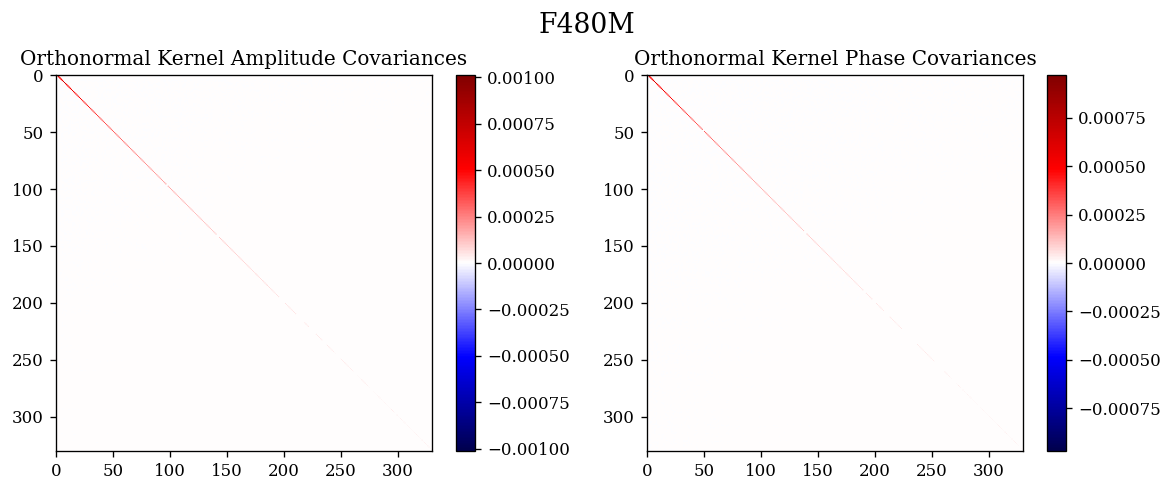

In [3]:
filters = ["F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis = np.load(
        f"/media/morgana1/snert/max/data/amigo_files/outputs/WR137/calIBRATED.npy",
        allow_pickle=True,
    ).item()

    vis = cal_vis["K_vis"]
    phi = cal_vis["K_phi"]
    vis_cov = cal_vis["K_vis_cov"]
    phi_cov = cal_vis["K_phi_cov"]

    vis_vals, vis_vecs = np.linalg.eig(vis_cov)
    phi_vals, phi_vecs = np.linalg.eig(phi_cov)

    vis_vals, vis_vecs = vis_vals.real, vis_vecs.real.T
    phi_vals, phi_vecs = phi_vals.real, phi_vecs.real.T

    new_vis_cov = np.dot(vis_vecs, np.dot(vis_cov, np.linalg.inv(vis_vecs)))
    new_phi_cov = np.dot(phi_vecs, np.dot(phi_cov, np.linalg.inv(phi_vecs)))

    new_vis = np.dot(vis_vecs, vis)
    new_phi = np.dot(phi_vecs, phi)

    cal_vis["vis"] = new_vis
    cal_vis["phi"] = new_phi
    cal_vis["vis_cov"] = new_vis_cov
    cal_vis["phi_cov"] = new_phi_cov
    cal_vis["K_vis_proj"] = vis_vecs
    cal_vis["K_phi_proj"] = phi_vecs

    cal_vis_outputs[filt] = cal_vis

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(new_vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Orthonormal Kernel Amplitude Covariances")
    plt.imshow(new_vis_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    v = np.nanmax(np.abs(new_phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Orthonormal Kernel Phase Covariances")
    plt.imshow(new_phi_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [4]:
import equinox as eqx
import zodiax as zdx


class AmigoOIData(zdx.Base):
    # Coordinates
    u: np.ndarray
    v: np.ndarray
    wavel: np.ndarray
    parang: np.ndarray

    # Latent Kernel Visibilities
    vis: np.ndarray
    d_vis: np.ndarray

    # Latent Kernel Phases
    phi: np.ndarray
    d_phi: np.ndarray

    # Latent space projection matrices
    vis_mat: np.ndarray  # Latent -> Pixel
    phi_mat: np.ndarray  # Latent -> Pixel

    def __init__(self, oi_data):
        """
        Default should have vis, phi as their _latent_ values
        """
        self.u = -np.array(oi_data["u"], dtype=float)
        self.v = -np.array(oi_data["v"], dtype=float)
        self.wavel = np.array(oi_data["wavel"], dtype=float)
        self.parang = np.array(oi_data["parang"], dtype=float)

        # Visibilities
        self.vis = np.array(oi_data["vis"], dtype=float)
        self.phi = np.array(oi_data["phi"], dtype=float)

        # Uncertainties
        self.d_phi = np.diag(oi_data["phi_cov"]) ** 0.5
        self.d_vis = np.diag(oi_data["vis_cov"]) ** 0.5

        pix_to_latent = np.linalg.pinv(np.array(oi_data["vis_mat"], dtype=float))
        latent_to_kernel = np.array(oi_data["K_vis_mat"], dtype=float)
        latent_to_ortho = np.array(oi_data["K_vis_proj"], dtype=float)
        proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
        proj_mat = np.dot(latent_to_ortho, proj_mat.T)
        self.vis_mat = proj_mat.T

        pix_to_latent = np.linalg.pinv(np.array(oi_data["phi_mat"], dtype=float))
        latent_to_kernel = np.array(oi_data["K_phi_mat"], dtype=float)
        latent_to_ortho = np.array(oi_data["K_phi_proj"], dtype=float)
        proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
        proj_mat = np.dot(latent_to_ortho, proj_mat.T)
        self.phi_mat = proj_mat.T

    def flatten_data(self):
        """Flatten closure phases and uncertainties."""
        vis_vec = np.concatenate([self.vis, self.phi])
        vis_err = np.concatenate([self.d_vis, self.d_phi])
        return vis_vec, vis_err

    def flatten_model(self, cvis):
        """
        cvis: complex visibilities from model
        Flatten model visibilities and phases.
        """
        # Project the visibilities to the latent
        log_cvis = np.log(cvis)
        log_vis, phi = log_cvis.real, log_cvis.imag

        vis = np.dot(log_vis, self.vis_mat)
        phi = np.dot(phi, self.phi_mat)
        return np.concatenate([vis, phi])

    def model(self, model_object):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = model_object.model(self.u, self.v, self.wavel)
        return self.flatten_model(cvis)

    # Overwrite this, it was a mistake from the beginning
    def __repr__(self):
        return eqx.Module.__repr__(self)

In [5]:
import amigo

eig_mats = zdx.experimental.deserialise(K_path + "eigmats.zdx")


optics = amigo.optical_models.AMIOptics()
otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
vis_model = amigo.vis_models.LogVisModel(
    eig_mats["amplitude"],
    eig_mats["phase"],
    otf_coords,
    # n_terms=450,
    n_terms=400,
)

model = amigo.core_models.AmigoModel(
    [],
    optics=optics,
    detector=None,
    read=None,
    vis_model=vis_model,
)

oi_obj = AmigoOIData(cal_vis_outputs["F480M"])

In [6]:
from scipy.datasets import ascent

dist = np.array(ascent())
# dist = dlu.downsample(dist, 4)
dist = dist / dist.sum()

In [7]:
pscale = model.psf_pixel_scale * model.oversample
wl = model.filters["F480M"][0].mean()

uv = dlu.MFT(
    phasor=dist,
    wavelength=oi_obj.wavel,
    pixel_scale_in=pscale,
    npixels_out=2 * model.vis_model.otf_coords.shape[-1],
    pixel_scale_out=0.5 * np.diff(model.vis_model.otf_coords[0, 0]).mean(),
)

uv = dlu.downsample(uv, 2, mean=True)

In [8]:
# fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
# ax[0].scatter(range(len(sicko_amp)), sicko_amp, label="Sicko Amplitude", color="C0")
# ax[0].axhline(0, color="k", lw=0.5)
# ax[0].set_title("Sicko Amplitudes")
# ax[1].scatter(range(len(sicko_phase)), sicko_phase, label="Sicko Phase", color="C1")
# ax[1].axhline(0, color="k", lw=0.5)
# ax[1].set_title("Sicko Phases")
# ax[0].set_xlabel("Sicko Mode")
# ax[1].set_xlabel("Sicko Mode")
# ax[0].set_ylabel("Amplitude")
# ax[1].set_ylabel("Phase")
# plt.tight_layout()
# plt.show()

In [13]:
class ResolvedOIFit(AmigoOIData):
    """
    Amigo OI Fit class
    """

    key: str

    def __init__(self, oi_data, key):
        self.key = key
        super().__init__(oi_data)

    def initialise_params(self, distribution):
        params = {}

        params["log_dist"] = self.get_key("log_dist"), np.log10(
            distribution / distribution.sum()
        )

        return params

    def get_key(self, param):

        match param:
            case "log_dist":
                return self.key

    def map_param(self, param):
        """
        The `key` argument will return only the _key_ extension of the parameter path,
        which is required for object initialisation.
        """

        # Map the appropriate parameter to the correct key
        if param in ["log_dist"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def model_sicko(self, model):

        pscale_in = model.psf_pixel_scale * model.oversample
        distribution = 10 ** model.params["log_dist"][self.get_key("log_dist")]

        # Getting regular visibilities
        uv = dlu.MFT(
            phasor=distribution,
            wavelength=self.wavel,
            pixel_scale_in=pscale_in,
            npixels_out=model.uv_npixels,
            pixel_scale_out=model.uv_pscale,
        )
        uv = dlu.downsample(uv, 2, mean=True)

        vis = uv.flatten()[: uv.size // 2]
        # vis = np.log(vis)  # log(Ae^{iphi}) = log(A) + i phi
        amp, phase = vis.real, vis.imag  # Do i need to do this?

        # Transform to the sicko basis
        sicko_amp = np.dot(amp, self.vis_mat)
        sicko_phase = np.dot(phase, self.phi_mat)

        return np.vstack([sicko_amp, sicko_phase])

    def __call__(self, model):
        """
        Call the model with the given parameters.
        """
        return self.model_sicko(model)


class ResolvedSickoModel(amigo.core_models.BaseModeller):

    uv_npixels: int
    uv_pscale: float
    oversample: float
    psf_pixel_scale: float

    def __init__(
        self,
        ois: list,
        distribution: np.ndarray,
        uv_npixels: int,
        uv_pscale: float,
        oversample: float = 1.0,
        psf_pixel_scale: float = 0.065524085,
    ):

        self.uv_npixels = uv_npixels
        self.oversample = oversample
        self.uv_pscale = uv_pscale
        self.psf_pixel_scale = psf_pixel_scale

        params = {}
        for oi in ois:
            param_dict = oi.initialise_params(distribution)
            for param, (key, value) in param_dict.items():
                if param not in params.keys():
                    params[param] = {}
                params[param][key] = value

        super().__init__(params)

In [14]:
ois = [ResolvedOIFit(oi_data, filt) for filt, oi_data in cal_vis_outputs.items()]

model = ResolvedSickoModel(
    ois,
    np.ones((80, 80)),
    uv_npixels=2 * vis_model.otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(vis_model.otf_coords[0, 0]).mean(),
)

In [58]:
def norm_fn(model, oi, args={}):
    params = model.params
    dist = 10 ** params["log_dist"][oi.get_key("log_dist")]
    dist = np.clip(dist, 0.0)
    log_dist = np.log10(dist / dist.sum())

    params["log_dist"][oi.get_key("log_dist")] = log_dist
    return model.set("params", params)


def loss_fn(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model).flatten()
    chi2 = -0.5 * np.sum(jax.scipy.stats.norm.logpdf(data, loc=model_vis, scale=err))
    return chi2, ()


loss_fn(model, ois[0])

(Array(2915442.73075871, dtype=float64), ())

In [105]:
n_epoch = 400

config = {
    "log_dist": sgd(2e-9, 0),
}

trainer = amigo.fitting.Trainer(
    loss_fn=loss_fn,
    cache=fisher_cache,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 2,915,442.72
Estimated run time: 0:00:02
Full Time: 0:00:02
Final Loss: 181,731.88


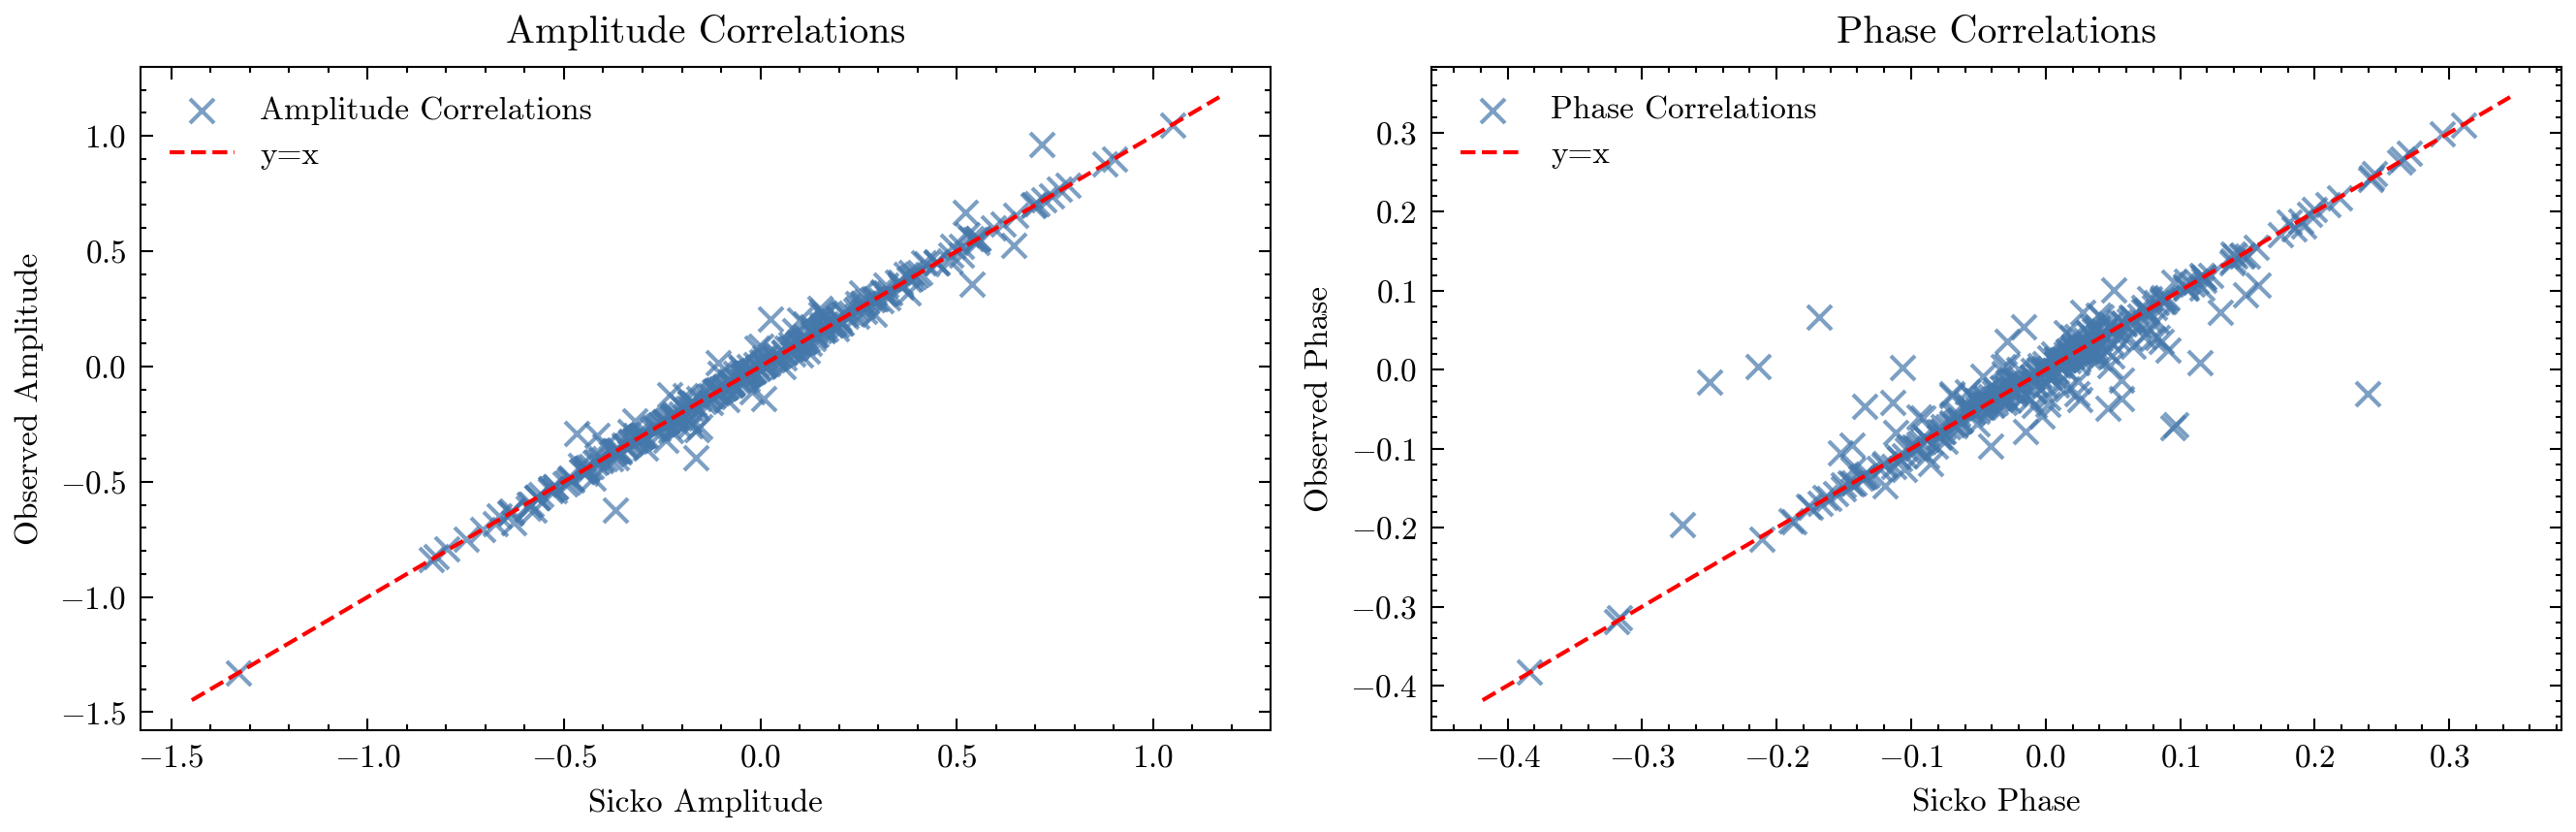

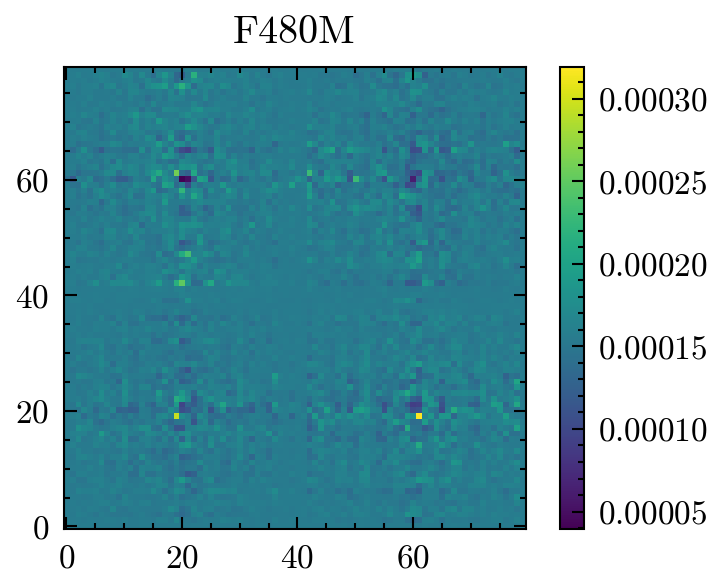

In [103]:
# amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
# amigo.plotting.plot(result.history)

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].scatter(
        sicko_amp,
        oi.vis,
        label="Amplitude Correlations",
        marker="x",
        alpha=0.7,
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Sicko Amplitude")
    ax[0].set_ylabel("Observed Amplitude")
    ax[0].legend()

    ax[1].scatter(
        sicko_phase,
        oi.phi,
        label="Phase Correlations",
        marker="x",
        alpha=0.7,
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Sicko Phase")
    ax[1].set_ylabel("Observed Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.imshow(dist, cmap="viridis")
    plt.colorbar()
    plt.title(oi.get_key("log_dist"))
    plt.show()